# Predicción de la calidad del vino blanco mediante regresión
**Materia:** SIS420
**Estudiante:** Espinoza Chiri Soledad Griselda
**Carrera:** Ing. de Sistemas

**Dataset:** Wine Quality
https://archive.ics.uci.edu/dataset/186/wine+quality

Este cuadernillo entrena tres variantes de un modelo de regresión sobre el mismo conjunto de datos, con el objetivo de predecir la **calidad** de un vino blanco (variable numérica entre 0 y 10) a partir de 11 propiedades fisicoquímicas medidas en laboratorio:

`fixed acidity`, `volatile acidity`, `citric acid`, `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`, `density`, `pH`, `sulphates`, `alcohol`.

El conjunto contiene **4898 ejemplos** (m ≥ 2000) y **11 propiedades** (n ≥ 10), por lo que cumple con los requisitos mínimos del ejercicio.

Se implementan y comparan tres enfoques para calcular los parámetros θ:

1. **Regresión lineal multivariable** entrenada con descenso por el gradiente.
2. **Regresión polinómica** (características expandidas a grado 2) entrenada con descenso por el gradiente.
3. **Ecuación de la normal**, aplicada tanto al modelo lineal como al polinómico, para obtener θ de forma directa (sin iteraciones).

Para cada caso se muestra la curva de convergencia del costo J(θ) y se evalúa el modelo sobre un conjunto de prueba independiente con más de 100 predicciones, comparando el valor real contra el valor predicho.

In [1]:
# Conectando / vinculando nuestro drive con la sesión de Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Librerías utilizadas

Se usa `numpy` para el cálculo vectorial (descenso por el gradiente y ecuación de la normal, implementados manualmente), `pandas` para la carga y exploración del dataset, y `matplotlib` para las gráficas de convergencia del costo y de resultados. `scikit-learn` se utiliza únicamente como apoyo para dividir el dataset en entrenamiento/prueba y para generar las características polinómicas de forma ordenada.

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline
np.random.seed(42)

Cargar Dataset

In [3]:
# Cargar el dataset desde Google Drive
ruta = '/content/drive/MyDrive/SIS420/LAB3/winequality-white.csv'

with open(ruta, 'r') as f:
    contenido = f.readlines()

print("Total de registros (incluye encabezado):", len(contenido))
print("Encabezado:", contenido[0].strip())
print("Vista previa:")
for fila in contenido[1:6]:
    print(fila.strip())

Total de registros (incluye encabezado): 4899
Encabezado: "fixed acidity";"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"
Vista previa:
7;0.27;0.36;20.7;0.045;45;170;1.001;3;0.45;8.8;6
6.3;0.3;0.34;1.6;0.049;14;132;0.994;3.3;0.49;9.5;6
8.1;0.28;0.4;6.9;0.05;30;97;0.9951;3.26;0.44;10.1;6
7.2;0.23;0.32;8.5;0.058;47;186;0.9956;3.19;0.4;9.9;6
7.2;0.23;0.32;8.5;0.058;47;186;0.9956;3.19;0.4;9.9;6


## 2. Carga y exploración del dataset

El archivo `winequality-white.csv` utiliza `;` como separador de columnas, tal como se distribuye en el repositorio UCI. Se cargan los datos con `pandas` y se separan las 11 propiedades fisicoquímicas (variables independientes, matriz $X$) de la variable objetivo `quality` (variable dependiente, vector $y$).

In [4]:
# Cargar el dataset desde Google Drive
ruta = '/content/drive/MyDrive/SIS420/LAB3/winequality-white.csv'

# Vista previa en texto plano (opcional, solo para inspección visual del archivo)
with open(ruta, 'r') as f:
    contenido = f.readlines()

print("Total de registros (incluye encabezado):", len(contenido))
print("Encabezado:", contenido[0].strip())
print("Vista previa:")
for fila in contenido[1:6]:
    print(fila.strip())

# Carga real con pandas (esta es la que usa el resto del cuadernillo)
df = pd.read_csv(ruta, sep=';')
print('\nDimensiones del dataset:', df.shape)
df.head()

Total de registros (incluye encabezado): 4899
Encabezado: "fixed acidity";"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"
Vista previa:
7;0.27;0.36;20.7;0.045;45;170;1.001;3;0.45;8.8;6
6.3;0.3;0.34;1.6;0.049;14;132;0.994;3.3;0.49;9.5;6
8.1;0.28;0.4;6.9;0.05;30;97;0.9951;3.26;0.44;10.1;6
7.2;0.23;0.32;8.5;0.058;47;186;0.9956;3.19;0.4;9.9;6
7.2;0.23;0.32;8.5;0.058;47;186;0.9956;3.19;0.4;9.9;6

Dimensiones del dataset: (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [5]:
# Verificación de que se cumplen los requisitos minimos del ejercicio
m_total, n_total = df.drop(columns=['quality']).shape
print(f'Numero de ejemplos (m) = {m_total}  ->  se requiere m >= 2000')
print(f'Numero de propiedades (n) = {n_total}  ->  se requiere n >= 10')
print('Valores nulos por columna:')
print(df.isnull().sum().sum(), 'valores nulos en total')

Numero de ejemplos (m) = 4898  ->  se requiere m >= 2000
Numero de propiedades (n) = 11  ->  se requiere n >= 10
Valores nulos por columna:
0 valores nulos en total


In [6]:
X = df.drop(columns=['quality']).values   # matriz de propiedades (4898 x 11)
y = df['quality'].values                  # vector objetivo (calidad del vino)

print('X:', X.shape)
print('y:', y.shape)

X: (4898, 11)
y: (4898,)


### 2.1 División en entrenamiento y prueba

Se separa el 80% de los ejemplos para entrenar los tres modelos y el 20% restante  para evaluar las predicciones sobre datos que el modelo no vio durante el entrenamiento.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
m_train = y_train.size
m_test = y_test.size
print('Ejemplos de entrenamiento:', m_train)
print('Ejemplos de prueba:', m_test)

Ejemplos de entrenamiento: 3918
Ejemplos de prueba: 980


## 3. Normalización de características

Las 11 propiedades del dataset tienen escalas muy distintas (por ejemplo, `total sulfur dioxide` toma valores de decenas mientras que `chlorides` toma valores cercanos a 0.05). Esta diferencia de escala hace que el descenso por el gradiente converja muy lentamente o incluso diverja, por lo que **antes de entrenar por descenso por el gradiente** se normaliza cada propiedad restando su media y dividiendo entre su desviación estándar.

La media y la desviación estándar se calculan **solo con el conjunto de entrenamiento**, y esos mismos valores se reutilizan para normalizar el conjunto de prueba; de esta forma no se filtra información del conjunto de prueba hacia el entrenamiento.

In [8]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

def applyNormalize(X, mu, sigma):
    return (X - mu) / sigma

## 4. Funciones de costo y descenso por el gradiente

Estas dos funciones son genéricas: sirven tanto para el modelo lineal multivariable como para el modelo polinómico, ya que en ambos casos se trata de un ajuste lineal de θ una vez que las características (originales o expandidas polinómicamente) ya están armadas en la matriz $X$.

La función de costo utilizada es el error cuadrático medio dividido entre 2:

$$ J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)}) - y^{(i)}\right)^2 $$

y la regla de actualización del descenso por el gradiente por lotes es:

$$ \theta_j := \theta_j - \frac{\alpha}{m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)}) - y^{(i)}\right)x_j^{(i)} $$

In [9]:
def computeCost(X, y, theta):
    m = y.shape[0]
    h = np.dot(X, theta)
    J = (1 / (2 * m)) * np.sum(np.square(h - y))
    return J

def gradientDescent(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = np.dot(X, theta)
        theta = theta - (alpha / m) * (np.dot(X.T, (h - y)))
        J_history.append(computeCost(X, y, theta))

    return theta, J_history

## 5. Modelo 1 — Regresión lineal multivariable (descenso por el gradiente)

Se entrena un modelo lineal que combina las 11 propiedades originales del vino:

$$ h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_{11} x_{11} $$

### 5.1 Preparación de la matriz de diseño

Se normalizan las 11 propiedades y se añade la columna de unos correspondiente al término independiente $\theta_0$.

In [10]:
X_train_norm, mu_lin, sigma_lin = featureNormalize(X_train)
X_test_norm = applyNormalize(X_test, mu_lin, sigma_lin)

X_train_lin = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_test_lin = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

print('X_train_lin:', X_train_lin.shape)
print('X_test_lin :', X_test_lin.shape)

X_train_lin: (3918, 12)
X_test_lin : (980, 12)


### 5.2 Entrenamiento con descenso por el gradiente

Se prueban distintas tasas de aprendizaje $\alpha$ para elegir una que converja de forma rápida y estable, tal como se hizo en el cuadernillo de clase para el caso univariable.

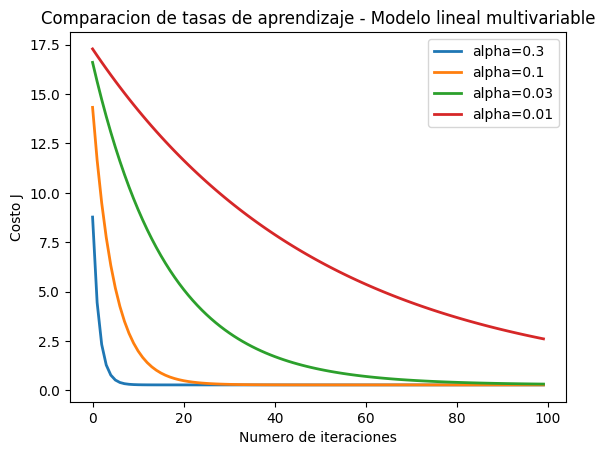

In [11]:
alphas = [0.3, 0.1, 0.03, 0.01]
num_iters_test = 100
plt.figure()
for a in alphas:
    theta_i = np.zeros(X_train_lin.shape[1])
    _, J_hist_i = gradientDescent(X_train_lin, y_train, theta_i, a, num_iters_test)
    plt.plot(np.arange(len(J_hist_i)), J_hist_i, lw=2, label=f'alpha={a}')
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J')
plt.title('Comparacion de tasas de aprendizaje - Modelo lineal multivariable')
plt.legend()
plt.show()

In [12]:
# Se elige alpha = 0.3, que converge rapido y de forma estable
alpha_lin = 0.3
num_iters_lin = 500

theta_lin = np.zeros(X_train_lin.shape[1])
theta_lin, J_history_lin = gradientDescent(X_train_lin, y_train, theta_lin, alpha_lin, num_iters_lin)

print('Theta obtenido (regresion lineal multivariable):')
print(theta_lin)

Theta obtenido (regresion lineal multivariable):
[ 5.87136294e+00  3.62613681e-02 -1.94828774e-01 -7.47989583e-03
  3.58900008e-01 -9.49331336e-04  8.58071927e-02 -1.06619927e-02
 -3.64494594e-01  8.81489243e-02  7.31077603e-02  2.86228739e-01]


### 5.3 Curva de convergencia del costo

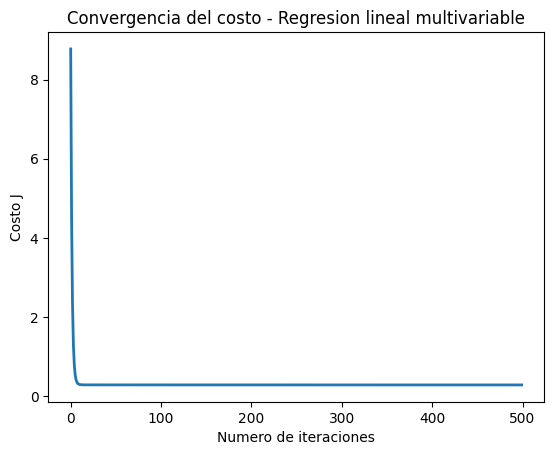

Costo inicial: 8.77495212924152
Costo final  : 0.2814152566242239


In [13]:
plt.figure()
plt.plot(np.arange(len(J_history_lin)), J_history_lin, lw=2, color='tab:blue')
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del costo - Regresion lineal multivariable')
plt.show()

print('Costo inicial:', J_history_lin[0])
print('Costo final  :', J_history_lin[-1])

### 5.4 Predicciones y evaluación sobre el conjunto de prueba

Se generan predicciones para los 980 ejemplos del conjunto de prueba y se calculan el error cuadrático medio (MSE), su raíz (RMSE) y el coeficiente de determinación $R^2$, que indica qué proporción de la variabilidad de la calidad del vino es explicada por el modelo.

In [14]:
y_pred_lin = np.dot(X_test_lin, theta_lin)

mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print(f'Numero de predicciones evaluadas: {y_pred_lin.size}')
print(f'MSE  = {mse_lin:.4f}')
print(f'RMSE = {rmse_lin:.4f}')
print(f'R2   = {r2_lin:.4f}')

Numero de predicciones evaluadas: 980
MSE  = 0.5693
RMSE = 0.7545
R2   = 0.2649


In [15]:
resultados_lin = pd.DataFrame({
    'calidad_real': y_test,
    'calidad_predicha': np.round(y_pred_lin, 2),
    'error_absoluto': np.round(np.abs(y_test - y_pred_lin), 2)
})
print(f'Se muestran las primeras 15 de un total de {len(resultados_lin)} predicciones:')
resultados_lin.head(15)

Se muestran las primeras 15 de un total de 980 predicciones:


,calidad_real,calidad_predicha,error_absoluto
0,7,6.37,0.63
1,8,6.40,1.60
2,8,6.41,1.59
3,5,5.83,0.83
4,7,6.44,0.56
5,6,6.37,0.37
6,5,5.24,0.24
7,4,5.48,1.48
8,6,6.08,0.08
9,5,5.33,0.33


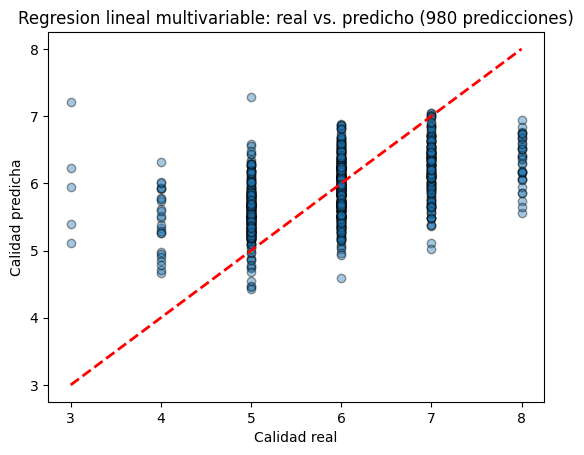

In [16]:
plt.figure()
plt.scatter(y_test, y_pred_lin, alpha=0.4, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Calidad real')
plt.ylabel('Calidad predicha')
plt.title('Regresion lineal multivariable: real vs. predicho (980 predicciones)')
plt.show()

## 6. Modelo 2 — Regresión polinómica (descenso por el gradiente)

Se expande cada una de las 11 propiedades originales agregando su término cuadrático y las combinaciones (interacciones) de segundo grado, mediante `PolynomialFeatures(degree=2)`. Con esto la hipótesis deja de ser una combinación lineal de las propiedades originales y pasa a poder capturar relaciones no lineales entre las propiedades fisicoquímicas y la calidad del vino.

Igual que en el modelo anterior, es indispensable normalizar las características expandidas antes de aplicar descenso por el gradiente, dado que los términos cuadráticos tienen una escala mucho mayor que los términos originales.

In [17]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_raw = poly.fit_transform(X_train)
X_test_poly_raw = poly.transform(X_test)

print('Propiedades originales:', X_train.shape[1])
print('Propiedades luego de la expansion polinomica (grado 2):', X_train_poly_raw.shape[1])

Propiedades originales: 11
Propiedades luego de la expansion polinomica (grado 2): 77


In [18]:
X_train_poly_norm, mu_poly, sigma_poly = featureNormalize(X_train_poly_raw)
X_test_poly_norm = applyNormalize(X_test_poly_raw, mu_poly, sigma_poly)

X_train_poly = np.concatenate([np.ones((m_train, 1)), X_train_poly_norm], axis=1)
X_test_poly = np.concatenate([np.ones((m_test, 1)), X_test_poly_norm], axis=1)

print('X_train_poly:', X_train_poly.shape)
print('X_test_poly :', X_test_poly.shape)

X_train_poly: (3918, 78)
X_test_poly : (980, 78)


### 6.1 Selección de la tasa de aprendizaje

Al tener muchas más características (77 en lugar de 11), el descenso por el gradiente es más sensible a la tasa de aprendizaje $\alpha$: valores que funcionaban bien en el modelo lineal (por ejemplo 0.3 o 0.1) hacen que el costo **diverja** en el modelo polinómico. Se prueban varias alternativas para elegir una tasa estable.

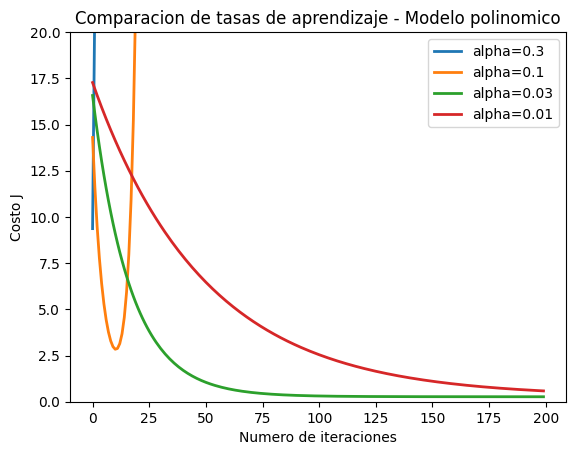

In [19]:
alphas_poly = [0.3, 0.1, 0.03, 0.01]
num_iters_test = 200
plt.figure()
for a in alphas_poly:
    theta_i = np.zeros(X_train_poly.shape[1])
    _, J_hist_i = gradientDescent(X_train_poly, y_train, theta_i, a, num_iters_test)
    plt.plot(np.arange(len(J_hist_i)), J_hist_i, lw=2, label=f'alpha={a}')
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J')
plt.title('Comparacion de tasas de aprendizaje - Modelo polinomico')
plt.ylim(0, 20)
plt.legend()
plt.show()

Como se observa en la gráfica, con $\alpha=0.3$ y $\alpha=0.1$ el costo diverge rápidamente (crece sin control), mientras que con $\alpha=0.03$ el costo desciende de forma estable. Por esta razón se entrena el modelo final con $\alpha=0.03$.

In [20]:
alpha_poly = 0.03
num_iters_poly = 500

theta_poly = np.zeros(X_train_poly.shape[1])
theta_poly, J_history_poly = gradientDescent(X_train_poly, y_train, theta_poly, alpha_poly, num_iters_poly)

print('Theta obtenido (regresion polinomica), primeros 10 valores:')
print(theta_poly[:10])

Theta obtenido (regresion polinomica), primeros 10 valores:
[ 5.87136151e+00  5.22853208e-03 -5.52188976e-02  1.66904744e-02
  5.64405516e-02  1.08378015e-02  5.40591379e-02  2.56445124e-02
 -1.07575658e-01  2.81248085e-03]


### 6.2 Curva de convergencia del costo

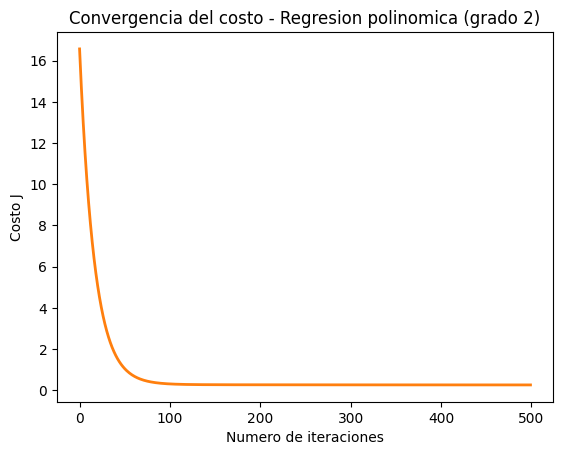

Costo inicial: 16.569958190294937
Costo final  : 0.26225061754286594


In [21]:
plt.figure()
plt.plot(np.arange(len(J_history_poly)), J_history_poly, lw=2, color='tab:orange')
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del costo - Regresion polinomica (grado 2)')
plt.show()

print('Costo inicial:', J_history_poly[0])
print('Costo final  :', J_history_poly[-1])

### 6.3 Predicciones y evaluación sobre el conjunto de prueba

In [22]:
y_pred_poly = np.dot(X_test_poly, theta_poly)

mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f'Numero de predicciones evaluadas: {y_pred_poly.size}')
print(f'MSE  = {mse_poly:.4f}')
print(f'RMSE = {rmse_poly:.4f}')
print(f'R2   = {r2_poly:.4f}')

Numero de predicciones evaluadas: 980
MSE  = 0.6236
RMSE = 0.7897
R2   = 0.1948


In [23]:
resultados_poly = pd.DataFrame({
    'calidad_real': y_test,
    'calidad_predicha': np.round(y_pred_poly, 2),
    'error_absoluto': np.round(np.abs(y_test - y_pred_poly), 2)
})
print(f'Se muestran las primeras 15 de un total de {len(resultados_poly)} predicciones:')
resultados_poly.head(15)

Se muestran las primeras 15 de un total de 980 predicciones:


,calidad_real,calidad_predicha,error_absoluto
0,7,6.34,0.66
1,8,6.57,1.43
2,8,6.45,1.55
3,5,5.85,0.85
4,7,6.41,0.59
5,6,6.18,0.18
6,5,5.22,0.22
7,4,5.29,1.29
8,6,5.92,0.08
9,5,5.06,0.06


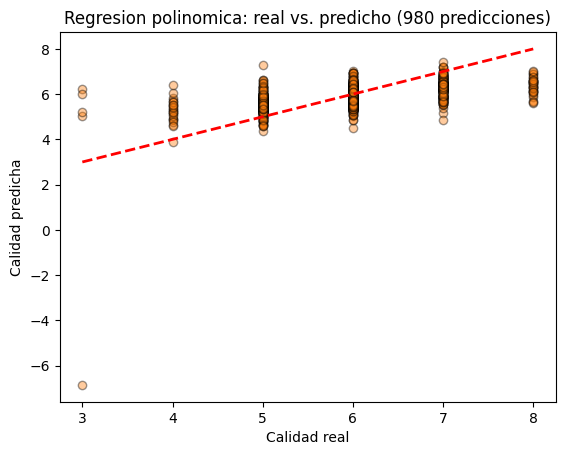

In [24]:
plt.figure()
plt.scatter(y_test, y_pred_poly, alpha=0.4, edgecolor='k', color='tab:orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Calidad real')
plt.ylabel('Calidad predicha')
plt.title('Regresion polinomica: real vs. predicho (980 predicciones)')
plt.show()

## 7. Modelo 3 — Ecuación de la normal

La ecuación de la normal calcula θ de forma directa, sin iteraciones y sin necesidad de normalizar las características:

$$ \theta = \left(X^T X\right)^{-1} X^T \vec{y} $$

Se aplica esta ecuación sobre dos versiones de la matriz de diseño para comparar ambos casos con sus contrapartes entrenadas por descenso por el gradiente:

- **7.1** usando las 11 propiedades originales (comparable con el modelo lineal multivariable de la sección 5).
- **7.2** usando las propiedades expandidas polinómicamente (comparable con el modelo polinómico de la sección 6).

En ambos casos se utilizan los datos **sin normalizar**, ya que la ecuación de la normal no lo requiere.

In [25]:
def normalEqn(X, y):
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)
    return theta

### 7.1 Ecuación de la normal con las propiedades originales

In [26]:
X_train_ne_lin = np.concatenate([np.ones((m_train, 1)), X_train], axis=1)
X_test_ne_lin = np.concatenate([np.ones((m_test, 1)), X_test], axis=1)

theta_ne_lin = normalEqn(X_train_ne_lin, y_train)
print('Theta obtenido (ecuacion de la normal, propiedades originales):')
print(theta_ne_lin)

Theta obtenido (ecuacion de la normal, propiedades originales):
[ 1.24393935e+02  4.59072530e-02 -1.91488430e+00 -6.13034627e-02
  7.12395584e-02 -2.64750361e-02  5.11945357e-03 -2.42153884e-04
 -1.24264146e+02  6.00699926e-01  6.49072810e-01  2.29008660e-01]


In [27]:
y_pred_ne_lin = np.dot(X_test_ne_lin, theta_ne_lin)

mse_ne_lin = mean_squared_error(y_test, y_pred_ne_lin)
rmse_ne_lin = np.sqrt(mse_ne_lin)
r2_ne_lin = r2_score(y_test, y_pred_ne_lin)

print(f'Numero de predicciones evaluadas: {y_pred_ne_lin.size}')
print(f'MSE  = {mse_ne_lin:.4f}')
print(f'RMSE = {rmse_ne_lin:.4f}')
print(f'R2   = {r2_ne_lin:.4f}')

Numero de predicciones evaluadas: 980
MSE  = 0.5690
RMSE = 0.7543
R2   = 0.2653


### 7.2 Ecuación de la normal con las propiedades polinómicas

Como la matriz $X^TX$ puede volverse casi singular al tener 77 columnas correlacionadas entre sí (por ejemplo `alcohol` y `alcohol^2`), se utiliza la pseudo-inversa (`np.linalg.pinv`) en lugar de la inversa estricta, lo que evita errores numéricos sin cambiar la idea central de la ecuación de la normal.

In [28]:
X_train_ne_poly = np.concatenate([np.ones((m_train, 1)), X_train_poly_raw], axis=1)
X_test_ne_poly = np.concatenate([np.ones((m_test, 1)), X_test_poly_raw], axis=1)

theta_ne_poly = normalEqn(X_train_ne_poly, y_train)
print('Theta obtenido (ecuacion de la normal, propiedades polinomicas), primeros 10 valores:')
print(theta_ne_poly[:10])

Theta obtenido (ecuacion de la normal, propiedades polinomicas), primeros 10 valores:
[  9.05939639  14.60936724  -6.1453721   -4.14409457 -11.79545108
   3.57662539  -2.13143879  -0.95041027   4.68547122   5.33742775]


In [29]:
y_pred_ne_poly = np.dot(X_test_ne_poly, theta_ne_poly)

mse_ne_poly = mean_squared_error(y_test, y_pred_ne_poly)
rmse_ne_poly = np.sqrt(mse_ne_poly)
r2_ne_poly = r2_score(y_test, y_pred_ne_poly)

print(f'Numero de predicciones evaluadas: {y_pred_ne_poly.size}')
print(f'MSE  = {mse_ne_poly:.4f}')
print(f'RMSE = {rmse_ne_poly:.4f}')
print(f'R2   = {r2_ne_poly:.4f}')

Numero de predicciones evaluadas: 980
MSE  = 0.6257
RMSE = 0.7910
R2   = 0.1921


In [30]:
resultados_ne_poly = pd.DataFrame({
    'calidad_real': y_test,
    'calidad_predicha': np.round(y_pred_ne_poly, 2),
    'error_absoluto': np.round(np.abs(y_test - y_pred_ne_poly), 2)
})
print(f'Se muestran las primeras 15 de un total de {len(resultados_ne_poly)} predicciones:')
resultados_ne_poly.head(15)

Se muestran las primeras 15 de un total de 980 predicciones:


,calidad_real,calidad_predicha,error_absoluto
0,7,6.12,0.88
1,8,6.84,1.16
2,8,6.52,1.48
3,5,5.92,0.92
4,7,6.50,0.50
5,6,6.39,0.39
6,5,5.46,0.46
7,4,5.17,1.17
8,6,6.06,0.06
9,5,4.86,0.14


## 8. Comparación de los tres enfoques

Se resumen las métricas obtenidas sobre el mismo conjunto de prueba (980 ejemplos) para los cuatro cálculos de θ realizados: los dos entrenados por descenso por el gradiente (secciones 5 y 6) y los dos calculados con la ecuación de la normal (secciones 7.1 y 7.2).

In [31]:
comparacion = pd.DataFrame({
    'Modelo': [
        'Lineal multivariable (descenso por el gradiente)',
        'Polinomico grado 2 (descenso por el gradiente)',
        'Lineal multivariable (ecuacion de la normal)',
        'Polinomico grado 2 (ecuacion de la normal)'
    ],
    'MSE': [mse_lin, mse_poly, mse_ne_lin, mse_ne_poly],
    'RMSE': [rmse_lin, rmse_poly, rmse_ne_lin, rmse_ne_poly],
    'R2': [r2_lin, r2_poly, r2_ne_lin, r2_ne_poly]
})
comparacion

,Modelo,MSE,RMSE,R2
0,Lineal multivariable (descenso por el gradiente),0.569343,0.754548,0.264864
1,Polinomico grado 2 (descenso por el gradiente),0.623637,0.789707,0.194760
2,Lineal multivariable (ecuacion de la normal),0.569025,0.754337,0.265275
3,Polinomico grado 2 (ecuacion de la normal),0.625706,0.791016,0.192088


### Conclusiones

1. Los modelos entrenados por **descenso por el gradiente** y su equivalente calculado con la **ecuación de la normal** obtienen métricas prácticamente idénticas en ambos casos (lineal y polinómico), lo cual confirma que ambos métodos convergen al mismo mínimo de la función de costo cuando el descenso por el gradiente se entrena con suficientes iteraciones y una tasa de aprendizaje adecuada.
2. En términos generales, el $R^2$ obtenido no es muy alto en ninguno de los cuatro casos (entre 0.19 y 0.27). Esto es esperable: la calidad del vino en este dataset fue asignada por catadores humanos mediante una escala subjetiva del 0 al 10, por lo que existe una componente de variabilidad que las propiedades fisicoquímicas por sí solas no pueden explicar completamente.
3. La **ecuación de la normal** resulta más directa de aplicar (un solo cálculo, sin elegir tasa de aprendizaje ni número de iteraciones), pero su costo computacional crece rápidamente con el número de características (al invertir una matriz de tamaño $n \times n$), lo que la hace menos práctica cuando, como en el caso polinómico, el número de columnas crece a 78. Además, con tantas columnas correlacionadas entre sí, la matriz $X^TX$ se vuelve casi singular, por lo que fue necesario usar la pseudo-inversa en lugar de la inversa estricta.